# LLM-Assisted DNN Recommendation Engine for Lenovo AI Infrastructure

This Google Colab notebook trains an AI-driven recommendation engine that maps AI workload requirements to one of four validated Lenovo server configurations.

## Target Classes

| Class | Configuration | GPU Profile | Intended Use |
|---|---|---|---|
| 0 | 221 SR650 | 2x NVIDIA RTX PRO 4500 Blackwell Server Edition | Edge AI, lightweight inference, small LLMs |
| 1 | 221 SR675 | 2x NVIDIA RTX PRO 6000 Blackwell Server Edition | Mid-size inference, RAG, vision AI |
| 2 | 285 | 8x NVIDIA H200 | Large-scale inference, fine-tuning, enterprise GenAI |
| 3 | 289 SR680 | 8x NVIDIA B200 | Large training, agentic AI, foundation models |

## Workflow

1. Load dataset  
2. EDA and plots  
3. Correlation analysis  
4. Feature selection  
5. Preprocessing  
6. Train/test split 80/20  
7. Validation split for DNN training  
8. Logistic Regression baseline  
9. TensorFlow/Keras Deep Neural Network  
10. Model comparison  
11. Export trained artifacts  
12. Example LLM-style feature extraction pipeline

In [ ]:
# ============================================================
# 1. Install required libraries
# ============================================================
!pip install -q openpyxl joblib
!pip install -q groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 10.1 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 2. Import libraries
# ============================================================
import os
import json
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from groq import Groq
import os
import json
from google.colab import userdata


GROQ_API_KEY = "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"

groq_client = Groq(api_key=GROQ_API_KEY)

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 3. Load Dataset


`lenovo_ai_infrastructure_recommendation_dataset.xlsx`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


file_name = "/content/drive/MyDrive/ColabNotebooks/Walsh/CapsProject2026/lenovo_ai_infrastructure_recommendation_dataset.xlsx"

df = pd.read_excel(file_name, sheet_name="Dataset")

print("Dataset shape:", df.shape)
df.head()

Mounted at /content/drive
Dataset shape: (1000, 31)


,request_id,conversation_text,industry,use_case,model_family,workload_type,model_parameter_size_b,concurrent_users,input_tokens,output_tokens,batch_size,latency_requirement,memory_requirement_gb,deployment_type,preferred_gpu_family,storage_requirement_tb,network_requirement_gbps,business_criticality,budget_sensitivity,workload_intensity_score,target_gpu_family,target_gpu_count,configuration_tier,recommended_server_configuration,deal_size_usd,conversion_rate,estimated_infrastructure_cost_usd,expected_revenue_usd,roi_percent,planning_time_hours,cost_per_decision_usd
0,REQ-0001,We need a medical imaging analysis solution fo...,Telecommunications,Medical imaging analysis,Computer Vision,Computer Vision,0.1,27,512,0,1,Medium,29,Edge,RTX PRO 6000 BSE,5.3,100,High,Performance-first,24.2,RTX PRO 6000 BSE,2,Mid-Size,221 SR675,291441,0.615,201876,179236,-11.21,6.2,1088.91
1,REQ-0002,I need infrastructure for a Multimodal project...,Education,Visual question answering,Multimodal,Inference,7.0,211,512,4096,4,Low,40,Edge,L40S,8.0,800,Mission Critical,Balanced,42.8,RTX PRO 6000 BSE,2,Mid-Size,221 SR675,704811,0.666,407268,469404,15.26,10.9,840.75
2,REQ-0003,I need infrastructure for a LLM project: docum...,Retail,Document summarization,LLM,Fine-tuning,70.0,1582,2048,512,2,Medium,923,Data Center,RTX PRO 6000 BSE,7.1,25,Medium,Performance-first,71.6,H200,8,High-End,285,839160,0.503,635070,422097,-33.54,14.9,2843.32
3,REQ-0004,Our team is building an AI system for Healthca...,Healthcare,Medical imaging analysis,Computer Vision,Computer Vision,3.0,4896,256,64,8,High,81,Data Center,RTX PRO 6000 BSE,7.1,400,Medium,Cost-sensitive,43.8,RTX PRO 6000 BSE,2,Mid-Size,221 SR675,327140,0.703,262186,229979,-12.28,8.3,984.96
4,REQ-0005,We need a predictive maintenance solution for ...,Financial Services,Predictive maintenance,Tabular ML,Inference,0.1,193,512,0,4,Medium,67,Enterprise,No preference,1.0,400,Mission Critical,Cost-sensitive,33.4,RTX PRO 4500 BSE,2,Edge,221 SR650,355142,0.695,218254,246823,13.09,2.7,470.48


## 4. Dataset Overview

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   request_id                         1000 non-null   object 
 1   conversation_text                  1000 non-null   object 
 2   industry                           1000 non-null   object 
 3   use_case                           1000 non-null   object 
 4   model_family                       1000 non-null   object 
 5   workload_type                      1000 non-null   object 
 6   model_parameter_size_b             1000 non-null   float64
 7   concurrent_users                   1000 non-null   int64  
 8   input_tokens                       1000 non-null   int64  
 9   output_tokens                      1000 non-null   int64  
 10  batch_size                         1000 non-null   int64  
 11  latency_requirement                1000 non-null   object

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
request_id,1000,1000,REQ-1000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
conversation_text,1000,1000,I need infrastructure for a Computer Vision pr...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
industry,1000,9,Financial Services,129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
use_case,1000,30,Customer support copilot,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_family,1000,6,LLM,273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
workload_type,1000,6,Inference,342,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_parameter_size_b,1000.0,NaN,NaN,NaN,36.8818,70.238898,0.1,3.0,8.0,34.0,405.0
concurrent_users,1000.0,NaN,NaN,NaN,1057.307,1219.060765,6.0,200.0,641.0,1327.25,4959.0
input_tokens,1000.0,NaN,NaN,NaN,6894.336,10007.884539,0.0,512.0,2048.0,8192.0,32000.0
output_tokens,1000.0,NaN,NaN,NaN,1007.04,1309.517943,0.0,128.0,256.0,1024.0,4096.0


In [ ]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

,0


## 5. Exploratory Data Analysis

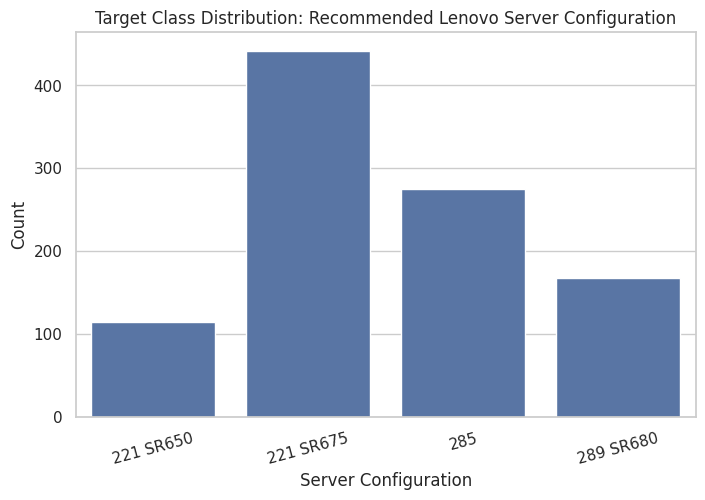

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="recommended_server_configuration", order=["221 SR650", "221 SR675", "285", "289 SR680"])
plt.title("Target Class Distribution: Recommended Lenovo Server Configuration")
plt.xlabel("Server Configuration")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.show()

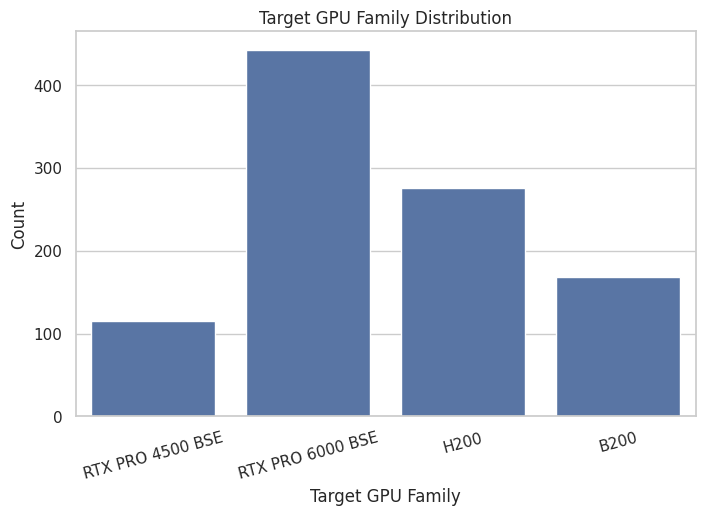

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="target_gpu_family", order=["RTX PRO 4500 BSE", "RTX PRO 6000 BSE", "H200", "B200"])
plt.title("Target GPU Family Distribution")
plt.xlabel("Target GPU Family")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.show()

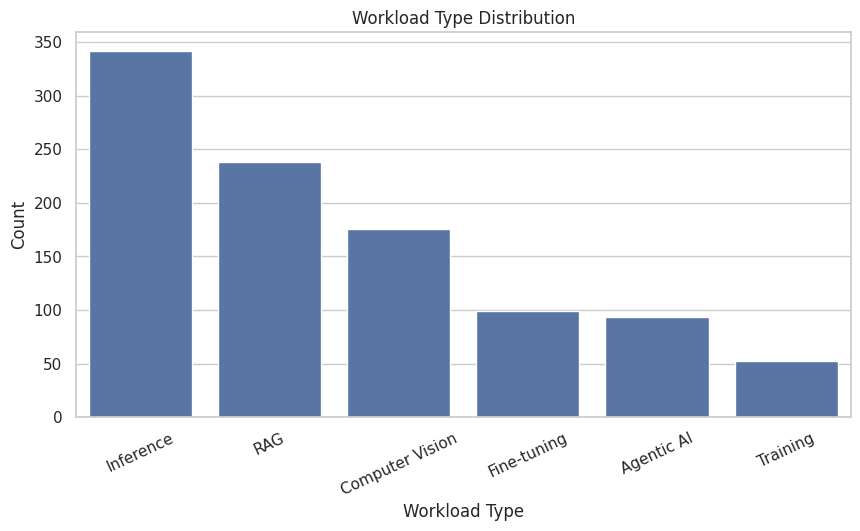

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="workload_type", order=df["workload_type"].value_counts().index)
plt.title("Workload Type Distribution")
plt.xlabel("Workload Type")
plt.ylabel("Count")
plt.xticks(rotation=25)
plt.show()

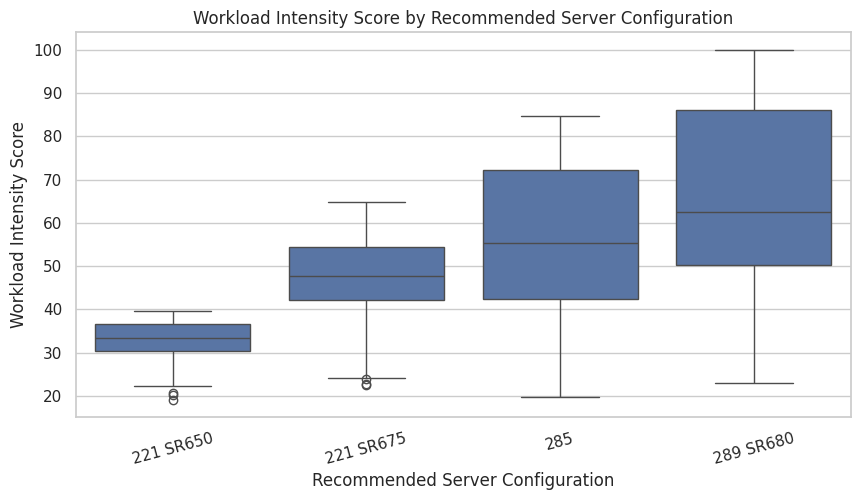

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="recommended_server_configuration", y="workload_intensity_score", order=["221 SR650", "221 SR675", "285", "289 SR680"])
plt.title("Workload Intensity Score by Recommended Server Configuration")
plt.xlabel("Recommended Server Configuration")
plt.ylabel("Workload Intensity Score")
plt.xticks(rotation=15)
plt.show()

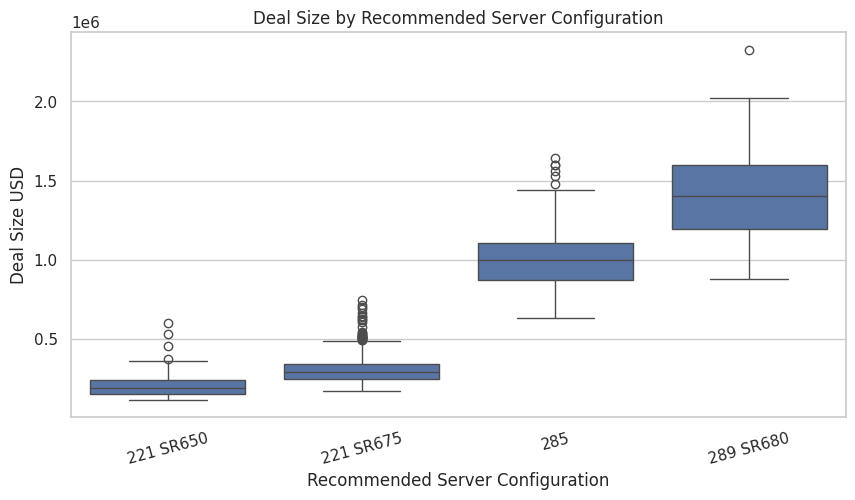

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="recommended_server_configuration", y="deal_size_usd", order=["221 SR650", "221 SR675", "285", "289 SR680"])
plt.title("Deal Size by Recommended Server Configuration")
plt.xlabel("Recommended Server Configuration")
plt.ylabel("Deal Size USD")
plt.xticks(rotation=15)
plt.show()

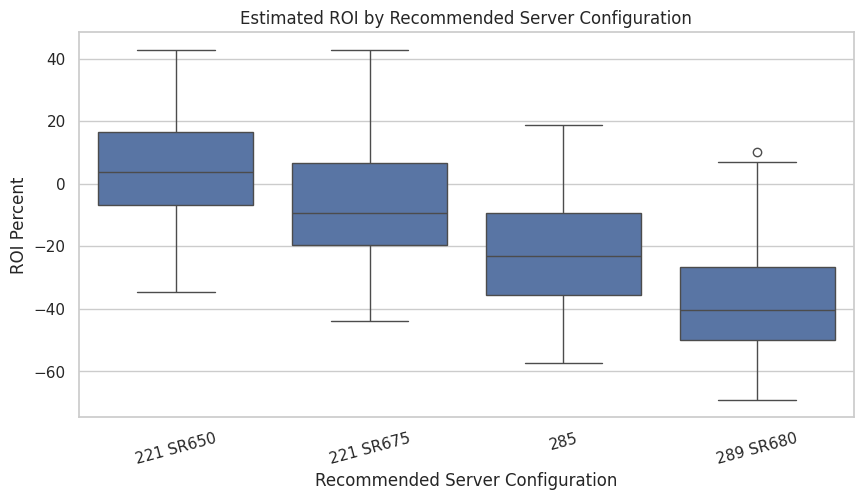

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="recommended_server_configuration", y="roi_percent", order=["221 SR650", "221 SR675", "285", "289 SR680"])
plt.title("Estimated ROI by Recommended Server Configuration")
plt.xlabel("Recommended Server Configuration")
plt.ylabel("ROI Percent")
plt.xticks(rotation=15)
plt.show()

## 6. Correlation Analysis

Correlation analysis should only use numeric columns. This helps identify relationships between workload intensity, model size, concurrency, cost, revenue, and ROI.

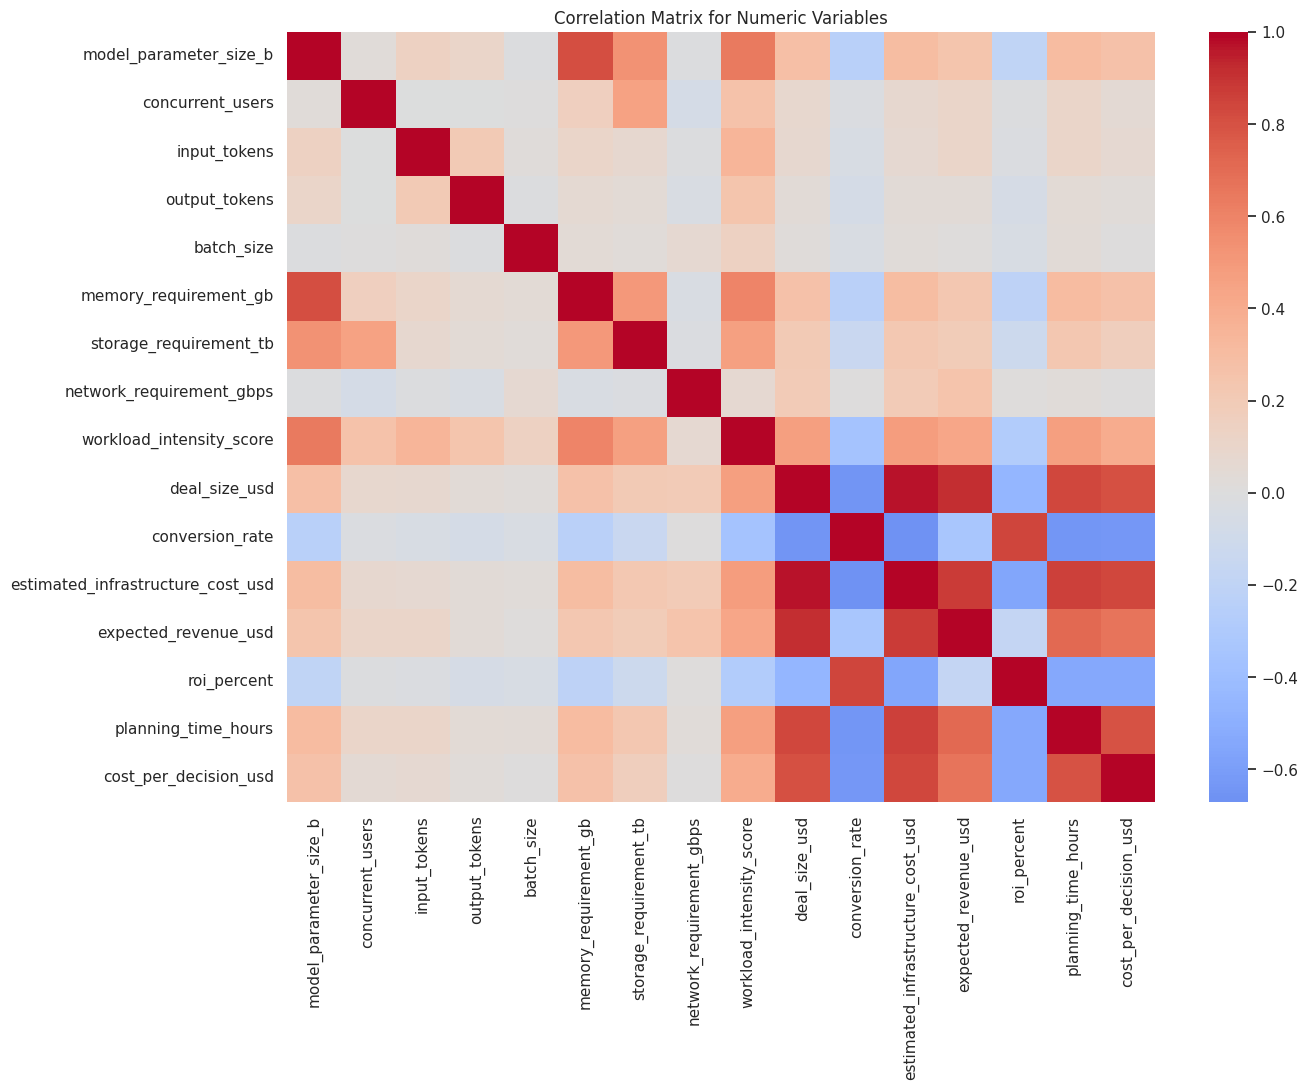

In [ ]:
numeric_cols = [
    "model_parameter_size_b",
    "concurrent_users",
    "input_tokens",
    "output_tokens",
    "batch_size",
    "memory_requirement_gb",
    "storage_requirement_tb",
    "network_requirement_gbps",
    "workload_intensity_score",
    "deal_size_usd",
    "conversion_rate",
    "estimated_infrastructure_cost_usd",
    "expected_revenue_usd",
    "roi_percent",
    "planning_time_hours",
    "cost_per_decision_usd"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Matrix for Numeric Variables")
plt.show()